In [2]:
"""
The most atomic way to train and run inference for a GPT in pure, dependency-free Python.
This file is the complete algorithm.
Everything else is just efficiency.
@karpathy

Adapted by Zdeněk Kasner
"""

import os       # os.path.exists
import math     # math.log, math.exp
import random   # random.seed, random.choices, random.gauss, random.shuffle
random.seed(42) # Let there be order among chaos


# ==============
# DATA LOADING
# ==============
# Let there be a Dataset `docs`: list[str] of documents (e.g. a list of names)
if not os.path.exists('input.txt'):
    import urllib.request
    names_url = 'https://raw.githubusercontent.com/karpathy/makemore/988aa59/names.txt'
    urllib.request.urlretrieve(names_url, 'input.txt')
docs = [line.strip() for line in open('input.txt') if line.strip()]
random.shuffle(docs)
print(f"num docs: {len(docs)}")

# Print a sample of the data
print()

print("sample docs:")
for doc in docs[:5]:
    print(f"  {doc}")



num docs: 32033

sample docs:
  yuheng
  diondre
  xavien
  jori
  juanluis


In [4]:
# =======================
# TOKENIZER (char-based)
# =======================

# Let there be a Tokenizer to translate strings to sequences of integers ("tokens") and back
uchars = sorted(set(''.join(docs))) # unique characters in the dataset become token ids 0..n-1
BOS = len(uchars) # token id for a special Beginning of Sequence (BOS) token
vocab_size = len(uchars) + 1 # total number of unique tokens, +1 is for BOS
print(f"vocab size: {vocab_size}")

print(uchars)

vocab size: 27
['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [14]:
# =========================
# CLASS FOR A SINGLE VALUE 
# =========================

# Let there be Autograd to recursively apply the chain rule through a computation graph
class Value:
    __slots__ = ('data', 'grad', '_children', '_local_grads') # Python optimization for memory usage

    def __init__(self, data, children=(), local_grads=()):
        self.data = data                # scalar value of this node calculated during forward pass
        self.grad = 0                   # derivative of the loss w.r.t. this node, calculated in backward pass
        self._children = children       # children of this node in the computation graph
        self._local_grads = local_grads # local derivative of this node w.r.t. its children

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1, 1))

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), (other.data, self.data))

    def __pow__(self, other): return Value(self.data**other, (self,), (other * self.data**(other-1),))
    def log(self): return Value(math.log(self.data), (self,), (1/self.data,))
    def exp(self): return Value(math.exp(self.data), (self,), (math.exp(self.data),))
    def relu(self): return Value(max(0, self.data), (self,), (float(self.data > 0),))
    def __neg__(self): return self * -1
    def __radd__(self, other): return self + other
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __rmul__(self, other): return self * other
    def __truediv__(self, other): return self * other**-1
    def __rtruediv__(self, other): return other * self**-1

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1
        for v in reversed(topo):
            for child, local_grad in zip(v._children, v._local_grads):
                child.grad += local_grad * v.grad

In [16]:
# =========================
# MODEL PARAMETERS
# =========================

# Initialize the parameters, to store the knowledge of the model
n_layer = 1     # depth of the transformer neural network (number of layers)
n_embd = 16     # width of the network (embedding dimension)
block_size = 16 # maximum context length of the attention window (note: the longest name is 15 characters)
n_head = 4      # number of attention heads
head_dim = n_embd // n_head # derived dimension of each head
matrix = lambda nout, nin, std=0.08: [[Value(random.gauss(0, std)) for _ in range(nin)] for _ in range(nout)]
state_dict = {'wte': matrix(vocab_size, n_embd), 'wpe': matrix(block_size, n_embd), 'lm_head': matrix(vocab_size, n_embd)}
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)
params = [p for mat in state_dict.values() for row in mat for p in row] # flatten params into a single list[Value]
print(f"num params: {len(params)}")

# print a sample of parameters
print()
print("sample params:")
for p in params[:50]:
    print(f"  {p.data:.4f}", end=' ')

num params: 4192

sample params:
  -0.1223   -0.0588   0.0271   0.1815   -0.0689   -0.0914   0.0637   0.0640   0.1339   -0.1536   -0.0895   -0.0912   -0.0101   -0.0046   0.1135   0.0498   -0.0907   0.0098   0.1145   0.1180   -0.1021   0.0689   0.1486   -0.0293   0.0438   0.0443   0.0118   0.0171   -0.0923   0.0565   0.1278   0.0443   -0.0127   -0.0620   0.1046   -0.1898   0.1027   -0.0631   0.0355   0.0478   0.0369   -0.0135   -0.1434   0.0367   -0.1399   0.1071   -0.0110   0.2027   -0.0492   0.0918 

In [17]:
# =========================
# MATH HELPERS 
# =========================
# Define the model architecture: a function mapping tokens and parameters to logits over what comes next
# Follow GPT-2, blessed among the GPTs, with minor differences: layernorm -> rmsnorm, no biases, GeLU -> ReLU
def linear(x, w):
    return [sum(wi * xi for wi, xi in zip(wo, x)) for wo in w]

def softmax(logits):
    max_val = max(val.data for val in logits)
    exps = [(val - max_val).exp() for val in logits]
    total = sum(exps)
    return [e / total for e in exps]

def rmsnorm(x):
    ms = sum(xi * xi for xi in x) / len(x)
    scale = (ms + 1e-5) ** -0.5
    return [xi * scale for xi in x]

In [19]:
# =========================
# MODEL LOGIC
# =========================

def gpt(token_id, pos_id, keys, values):
    tok_emb = state_dict['wte'][token_id] # token embedding
    pos_emb = state_dict['wpe'][pos_id] # position embedding
    x = [t + p for t, p in zip(tok_emb, pos_emb)] # joint token and position embedding
    x = rmsnorm(x) # note: not redundant due to backward pass via the residual connection

    for li in range(n_layer):
        # 1) Multi-head Attention block
        x_residual = x
        x = rmsnorm(x)
        q = linear(x, state_dict[f'layer{li}.attn_wq'])
        k = linear(x, state_dict[f'layer{li}.attn_wk'])
        v = linear(x, state_dict[f'layer{li}.attn_wv'])
        keys[li].append(k)
        values[li].append(v)
        x_attn = []
        for h in range(n_head):
            hs = h * head_dim
            q_h = q[hs:hs+head_dim]
            k_h = [ki[hs:hs+head_dim] for ki in keys[li]]
            v_h = [vi[hs:hs+head_dim] for vi in values[li]]
            attn_logits = [sum(q_h[j] * k_h[t][j] for j in range(head_dim)) / head_dim**0.5 for t in range(len(k_h))]
            attn_weights = softmax(attn_logits)
            head_out = [sum(attn_weights[t] * v_h[t][j] for t in range(len(v_h))) for j in range(head_dim)]
            x_attn.extend(head_out)
        x = linear(x_attn, state_dict[f'layer{li}.attn_wo'])
        x = [a + b for a, b in zip(x, x_residual)]
        # 2) MLP block
        x_residual = x
        x = rmsnorm(x)
        x = linear(x, state_dict[f'layer{li}.mlp_fc1'])
        x = [xi.relu() for xi in x]
        x = linear(x, state_dict[f'layer{li}.mlp_fc2'])
        x = [a + b for a, b in zip(x, x_residual)]

    logits = linear(x, state_dict['lm_head'])
    return logits

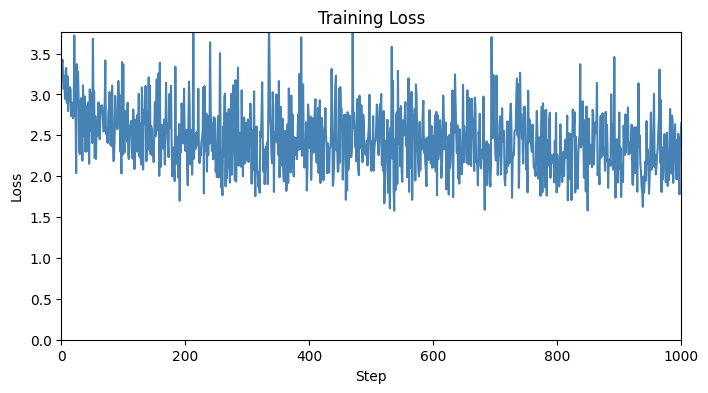

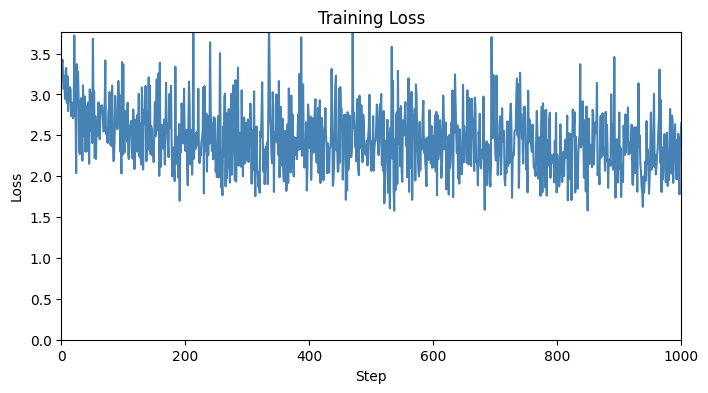


Final loss: 2.6497


In [ ]:
# ==============
# TRAINING LOOP
# ==============
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# Let there be Adam, the blessed optimizer and its buffers
learning_rate, beta1, beta2, eps_adam = 0.01, 0.85, 0.99, 1e-8
m = [0.0] * len(params) # first moment buffer
v = [0.0] * len(params) # second moment buffer

num_steps = 1000 # number of training steps

# Set up live loss plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training Loss")
ax.set_xlim(0, num_steps)
line, = ax.plot([], [], lw=1.5, color='steelblue')
display(fig)

loss_history = []

# Repeat in sequence
for step in range(num_steps):

    # Take single document, tokenize it, surround it with BOS special token on both sides
    doc = docs[step % len(docs)]
    tokens = [BOS] + [uchars.index(ch) for ch in doc] + [BOS]
    n = min(block_size, len(tokens) - 1)

    # Forward the token sequence through the model, building up the computation graph all the way to the loss
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    losses = []
    for pos_id in range(n):
        token_id, target_id = tokens[pos_id], tokens[pos_id + 1]
        logits = gpt(token_id, pos_id, keys, values)
        probs = softmax(logits)
        loss_t = -probs[target_id].log()
        losses.append(loss_t)
    loss = (1 / n) * sum(losses) # final average loss over the document sequence. May yours be low.

    # Backward the loss, calculating the gradients with respect to all model parameters
    loss.backward()

    # Adam optimizer update: update the model parameters based on the corresponding gradients
    lr_t = learning_rate * (1 - step / num_steps) # linear learning rate decay
    for i, p in enumerate(params):
        m[i] = beta1 * m[i] + (1 - beta1) * p.grad
        v[i] = beta2 * v[i] + (1 - beta2) * p.grad ** 2
        m_hat = m[i] / (1 - beta1 ** (step + 1))
        v_hat = v[i] / (1 - beta2 ** (step + 1))
        p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)
        p.grad = 0

    loss_history.append(loss.data)

    # Update live plot every 10 steps
    if (step + 1) % 10 == 0 or step == num_steps - 1:
        line.set_data(range(1, len(loss_history) + 1), loss_history)
        ax.set_ylim(0, max(loss_history[:10]) * 1.1)  # fix y-axis to early max for stability
        ax.relim()
        ax.autoscale_view(scaley=True)
        clear_output(wait=True)
        display(fig)
        print(f"step {step+1:4d} / {num_steps:4d} | loss {loss.data:.4f}", end='\r')

plt.show()
print(f"\nFinal loss: {loss.data:.4f}")


In [20]:
# ==============
# INFERENCE LOOP
# ==============

# Inference: may the model babble back to us
temperature = 0.5 # in (0, 1], control the "creativity" of generated text, low to high
print("\n--- inference (new, hallucinated names) ---")
for sample_idx in range(20):
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    for pos_id in range(block_size):
        logits = gpt(token_id, pos_id, keys, values)
        probs = softmax([l / temperature for l in logits])
        token_id = random.choices(range(vocab_size), weights=[p.data for p in probs])[0]
        if token_id == BOS:
            break
        sample.append(uchars[token_id])
    print(f"sample {sample_idx+1:2d}: {''.join(sample)}")


--- inference (new, hallucinated names) ---
sample  1: cawnsdanabmdptkt
sample  2: ofaiylfzkiswxrkn
sample  3: rfypwhqj
sample  4: g
sample  5: ltkruz
sample  6: xqpy
sample  7: qa
sample  8: zbrjaujlpbtdwuyp
sample  9: qqkh
sample 10: wgjxleaioqbjvvur
sample 11: ehcysjd
sample 12: jbedzec
sample 13: x
sample 14: e
sample 15: j
sample 16: vai
sample 17: yipvfqmvpypruhqo
sample 18: jqbxomxgsezyrxcj
sample 19: xlkmnqrjkbboorwr


KeyboardInterrupt: 